# 📱 Redes Sociais e Saúde Mental: Uma Análise Estatística do Comportamento de Estudantes

**Dataset:** [Students' Social Media Addiction — Kaggle](https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships)  
**Ferramentas:** Python · Pandas · Seaborn · Matplotlib · SciPy · SQLite  

---

## 🎯 Contexto e Perguntas de Negócio

O uso de redes sociais entre estudantes cresceu significativamente na última década. Mas afinal, **esse uso impacta objetivamente a saúde mental, o sono e o desempenho acadêmico?**

Este projeto analisa um dataset com 705 estudantes de 16 a 25 anos de 10 países, coletado no primeiro trimestre de 2025. As perguntas que guiam a análise são:

1. **Qual o perfil de uso** — quantas horas por dia, quais plataformas, qual o nível de dependência?
2. **Uso intensivo está associado a pior saúde mental?** E a menos horas de sono?
3. **Existe diferença de comportamento** entre níveis acadêmicos e gêneros?
4. **Uso excessivo impacta o desempenho acadêmico?** Os próprios estudantes percebem isso?
5. **Qual plataforma está mais associada a altos níveis de dependência?**

---

### Variáveis utilizadas

| Variável | Tipo | Descrição |
|---|---|---|
| `Age` | Inteiro | Idade do estudante |
| `Gender` | Categórica | Male / Female |
| `Academic_Level` | Categórica | High School / Undergraduate / Graduate |
| `Avg_Daily_Usage_Hours` | Contínua | Média de horas diárias em redes sociais |
| `Most_Used_Platform` | Categórica | Plataforma principal |
| `Affects_Academic_Performance` | Booleana | Impacto autopercebido no desempenho (Yes/No) |
| `Sleep_Hours_Per_Night` | Contínua | Média de horas de sono por noite |
| `Mental_Health_Score` | Discreta | Score de saúde mental (1–10) |
| `Addicted_Score` | Discreta | Score de dependência (1–10) |

---
## 1. Configuração e Carregamento dos Dados

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency
from scipy import stats
import sqlite3
import warnings
from google.colab import files # Correção: alterado de google.files para google.colab
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
COR_PRINCIPAL = '#2C7BB6'
COR_DESTAQUE  = '#D7191C'
CORES_GENERO  = {'Female': '#E87A7A', 'Male': '#7ABBE8'}

# Carregamento
uploaded = files.upload()
df = pd.read_csv('social_media_students.csv')
print(f'Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Saving social_media_students.csv to social_media_students.csv
Dataset carregado: 705 linhas × 13 colunas


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


---
## 2. Análise Exploratória de Dados (EDA)

### 2.1 Visão Geral e Qualidade dos Dados

In [4]:
# Tipos, nulos e estatísticas gerais
print('*** TIPOS E NULOS ***')
print(df.dtypes)
print(f'\nValores nulos por coluna:\n{df.isnull().sum()}')

*** TIPOS E NULOS ***
Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Valores nulos por coluna:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_

In [5]:
# Estatísticas descritivas das variáveis numéricas
colunas_numericas = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                     'Mental_Health_Score', 'Addicted_Score', 'Age']

desc = df[colunas_numericas].describe().T
desc.columns = ['n', 'Média', 'Desvio Padrão', 'Mínimo', 'Q1', 'Mediana', 'Q3', 'Máximo']
desc = desc.round(2)
print('*** ESTATÍSTICAS DESCRITIVAS ***')
desc

*** ESTATÍSTICAS DESCRITIVAS ***


,n,Média,Desvio Padrão,Mínimo,Q1,Mediana,Q3,Máximo
Avg_Daily_Usage_Hours,705.0,4.92,1.26,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,705.0,6.87,1.13,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,6.23,1.11,4.0,5.0,6.0,7.0,9.0
Addicted_Score,705.0,6.44,1.59,2.0,5.0,7.0,8.0,9.0
Age,705.0,20.66,1.40,18.0,19.0,21.0,22.0,24.0


### 2.2 Distribuição das Variáveis Quantitativas

Para cada variável numérica, analisamos o histograma (distribuição de frequências) e o boxplot (dispersão e outliers).

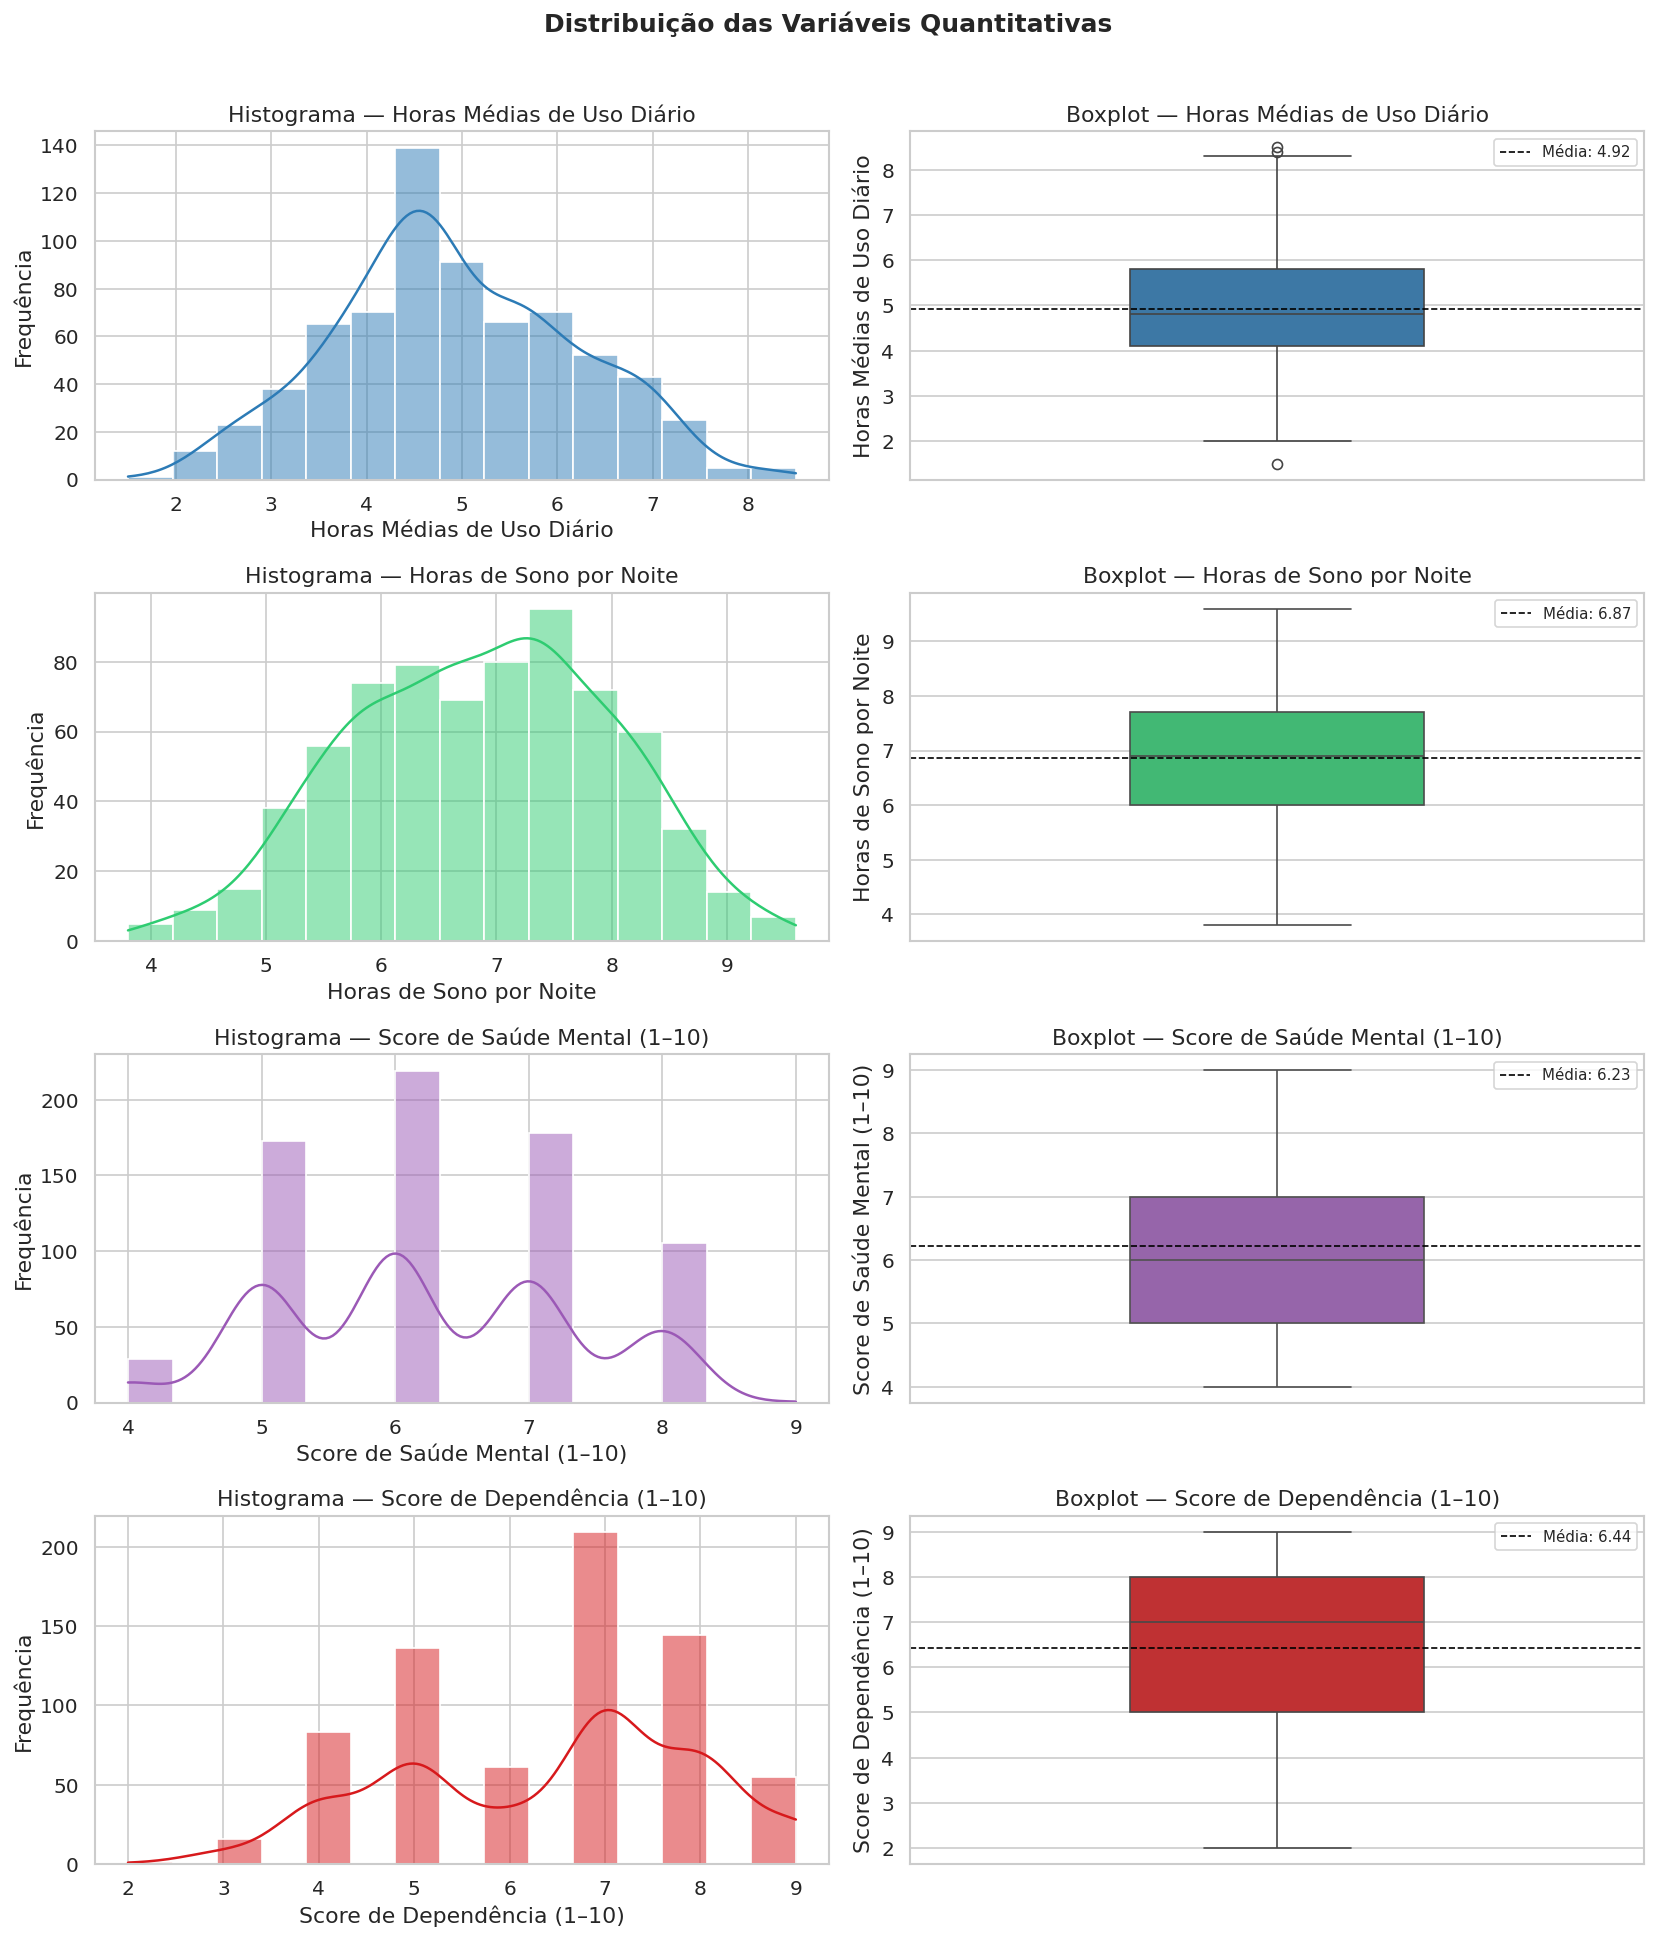

In [6]:
variaveis = {
    'Avg_Daily_Usage_Hours': ('Horas Médias de Uso Diário', COR_PRINCIPAL),
    'Sleep_Hours_Per_Night': ('Horas de Sono por Noite', '#2ECC71'),
    'Mental_Health_Score':   ('Score de Saúde Mental (1–10)', '#9B59B6'),
    'Addicted_Score':        ('Score de Dependência (1–10)', COR_DESTAQUE),
}

fig, axes = plt.subplots(len(variaveis), 2, figsize=(14, 4 * len(variaveis)))
fig.suptitle('Distribuição das Variáveis Quantitativas', fontsize=15, fontweight='bold', y=1.01)

for i, (col, (label, cor)) in enumerate(variaveis.items()):
    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color=cor, bins=15)
    axes[i, 0].set_title(f'Histograma — {label}')
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel('Frequência')

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i, 1], color=cor, width=0.4)
    media = df[col].mean()
    mediana = df[col].median()
    axes[i, 1].axhline(media, color='black', linestyle='--', linewidth=1, label=f'Média: {media:.2f}')
    axes[i, 1].set_title(f'Boxplot — {label}')
    axes[i, 1].set_ylabel(label)
    axes[i, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribuicoes.png', bbox_inches='tight')
plt.show()


**Interpretação:**
- **Uso diário:** distribuição levemente assimétrica à direita. A mediana (~4,8h) sugere que metade dos estudantes passa quase 5 horas por dia em redes sociais.
- **Sono:** distribuição próxima de simétrica, com valores concentrados entre 6 e 8 horas.
- **Saúde mental e dependência:** scores com dispersão moderada, indicando heterogeneidade nas respostas.

> Nenhuma variável apresentou outliers extremos que justifiquem remoção.

### 2.3 Distribuição das Variáveis Qualitativas

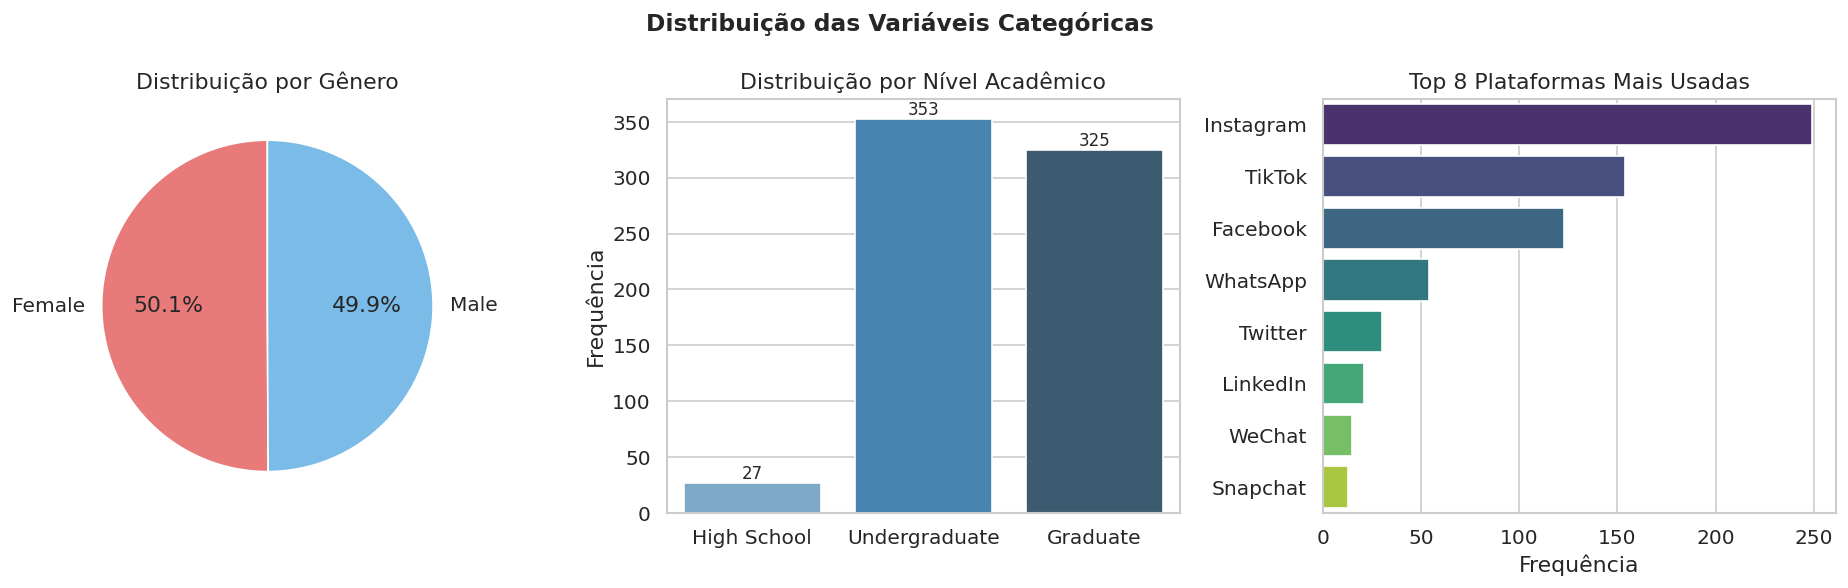

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=14, fontweight='bold')

# Gênero
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[CORES_GENERO['Female'], CORES_GENERO['Male']], startangle=90)
axes[0].set_title('Distribuição por Gênero')

# Nível acadêmico
order_acad = ['High School', 'Undergraduate', 'Graduate']
acad_counts = df['Academic_Level'].value_counts().reindex(order_acad)
sns.barplot(x=acad_counts.index, y=acad_counts.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Distribuição por Nível Acadêmico')
axes[1].set_xlabel('')
axes[1].set_ylabel('Frequência')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Plataforma mais usada
platform_counts = df['Most_Used_Platform'].value_counts().head(8)
sns.barplot(y=platform_counts.index, x=platform_counts.values, ax=axes[2], palette='viridis')
axes[2].set_title('Top 8 Plataformas Mais Usadas')
axes[2].set_xlabel('Frequência')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('categoricas.png', bbox_inches='tight')
plt.show()

**Observações:**
- A amostra é praticamente equilibrada por gênero (50/50).
- Predominância de estudantes de graduação e pós-graduação — apenas 27 do ensino médio, o que limita comparações para esse grupo.
- **Instagram é a plataforma dominante** (35%), seguida de TikTok (22%) e Facebook (17%).

---
## 3. Análise Estatística

### 3.1 Correlação de Spearman: Uso vs. Saúde Mental

Utilizamos a Correlação de Spearman (e não Pearson) pois as variáveis de score não seguem necessariamente uma distribuição normal — o Spearman avalia a relação entre os rankings, sendo mais robusto para dados ordinais.

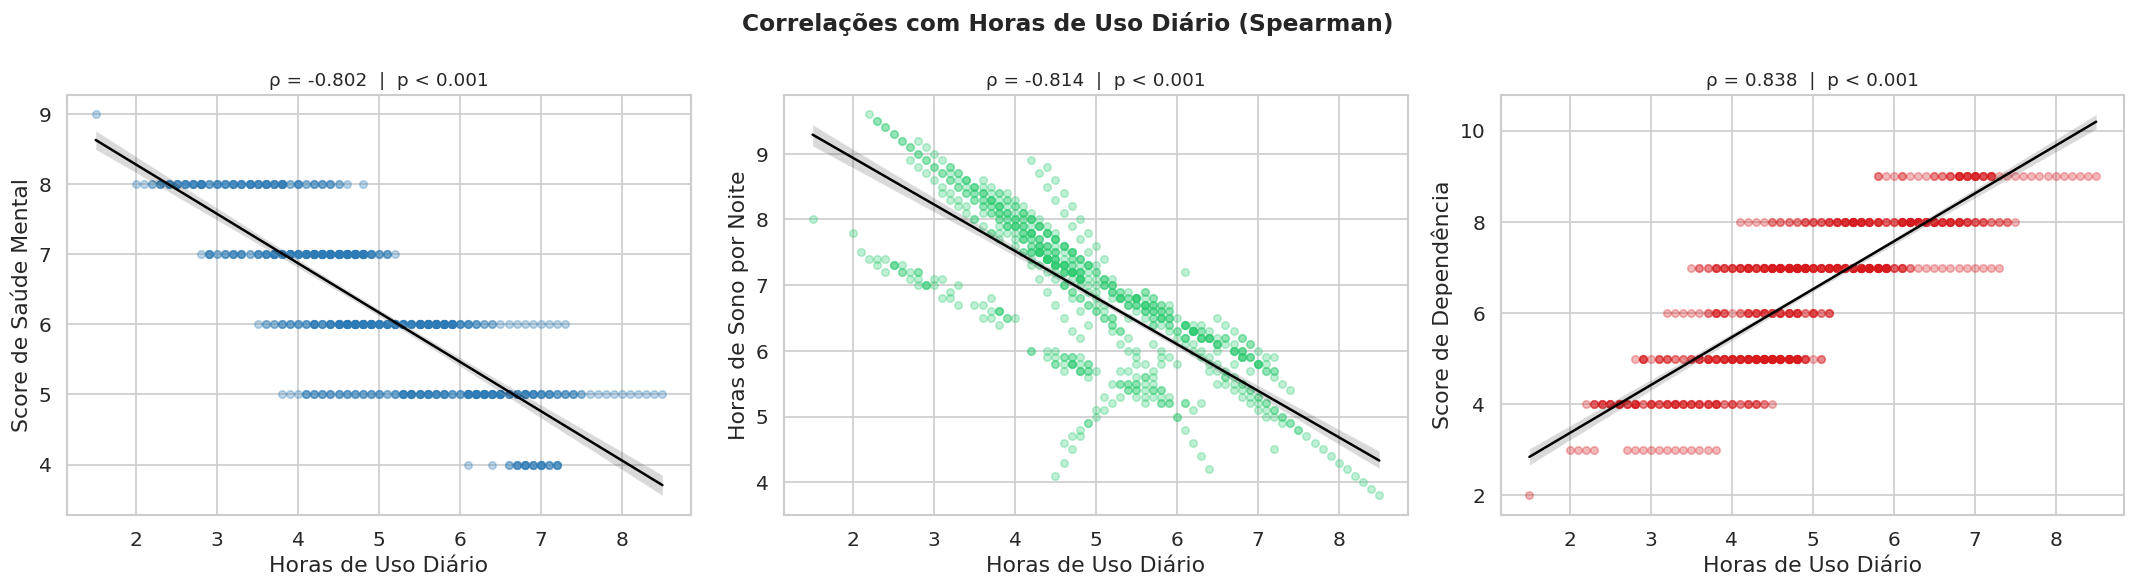


*** RESUMO DAS CORRELAÇÕES ***
Horas de Uso Diário × Score de Saúde Mental: ρ = -0.802 | p-valor = 2.20e-159
Horas de Uso Diário × Horas de Sono por Noite: ρ = -0.814 | p-valor = 2.30e-168
Horas de Uso Diário × Score de Dependência: ρ = 0.838 | p-valor = 4.16e-187


In [8]:
pares = [
    ('Avg_Daily_Usage_Hours', 'Mental_Health_Score',
     'Horas de Uso Diário', 'Score de Saúde Mental', COR_PRINCIPAL),
    ('Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
     'Horas de Uso Diário', 'Horas de Sono por Noite', '#2ECC71'),
    ('Avg_Daily_Usage_Hours', 'Addicted_Score',
     'Horas de Uso Diário', 'Score de Dependência', COR_DESTAQUE),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Correlações com Horas de Uso Diário (Spearman)', fontsize=14, fontweight='bold')

for ax, (x, y, xlabel, ylabel, cor) in zip(axes, pares):
    rho, p = spearmanr(df[x], df[y])
    sns.regplot(data=df, x=x, y=y, ax=ax,
                scatter_kws={'alpha': 0.3, 'color': cor, 's': 20},
                line_kws={'color': 'black', 'linewidth': 1.5})
    significancia = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'ρ = {rho:.3f}  |  {significancia}', fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig('correlacoes_spearman.png', bbox_inches='tight')
plt.show()

print('\n*** RESUMO DAS CORRELAÇÕES ***')
for x, y, xlabel, ylabel, _ in pares:
    rho, p = spearmanr(df[x], df[y])
    print(f'{xlabel} × {ylabel}: ρ = {rho:.3f} | p-valor = {p:.2e}')

**Interpretação:**

| Relação | ρ de Spearman | Interpretação |
|---|---|---|
| Uso × Saúde Mental | ~−0.80 | Correlação negativa **muito forte** |
| Uso × Sono | ~−0.81 | Correlação negativa **muito forte** |
| Uso × Dependência | ~+0.85 | Correlação positiva **muito forte** |

> **Insight:** Quanto maior o tempo de uso diário, pior a saúde mental, menos horas de sono, e maior o score de dependência — e todas as relações são estatisticamente significativas (p < 0.001).

> **Obs:** Correlação não implica causalidade. Outros fatores (estresse acadêmico, condições socioeconômicas) podem influenciar esses resultados.

### 3.2 Teste de Hipótese: Uso intensivo e Saúde Mental

**H₀:** Não existe correlação entre horas de uso e saúde mental.  
**H₁:** Existe correlação negativa significativa — quanto maior o uso, pior a saúde mental.

Usando o teste t de Student para validar a significância do coeficiente de Spearman:

In [9]:
def teste_hipotese_spearman(col_x, col_y, label_x, label_y):
    n = len(df)
    rho, p = spearmanr(df[col_x], df[col_y])
    df_gl = n - 2
    t_calc = rho * np.sqrt(df_gl / (1 - rho**2))
    valor_critico = 1.96  # α = 0.05, bicaudal

    print(f'\n{'*'*55}')
    print(f'  TESTE: {label_x} × {label_y}')
    print(f'{'*'*55}')
    print(f'  Coeficiente de Spearman (ρ): {rho:.4f}')
    print(f'  Graus de liberdade (df):     {df_gl}')
    print(f'  Estatística t calculada:     {t_calc:.2f}')
    print(f'  Valor crítico (α=0.05):      ±{valor_critico}')
    print(f'  p-valor:                     {p:.2e}')
    print(f'  Conclusão: ', end='')
    if abs(t_calc) > valor_critico:
        print(f'|t| = {abs(t_calc):.2f} > {valor_critico} → REJEITA H₀ ✅')
        print(f'  Existe correlação estatisticamente significativa.')
    else:
        print(f'|t| = {abs(t_calc):.2f} < {valor_critico} → NÃO rejeita H₀')

teste_hipotese_spearman('Avg_Daily_Usage_Hours', 'Mental_Health_Score',
                        'Uso Diário', 'Saúde Mental')
teste_hipotese_spearman('Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                        'Uso Diário', 'Horas de Sono')


*******************************************************
  TESTE: Uso Diário × Saúde Mental
*******************************************************
  Coeficiente de Spearman (ρ): -0.8019
  Graus de liberdade (df):     703
  Estatística t calculada:     -35.58
  Valor crítico (α=0.05):      ±1.96
  p-valor:                     2.20e-159
  Conclusão: |t| = 35.58 > 1.96 → REJEITA H₀ ✅
  Existe correlação estatisticamente significativa.

*******************************************************
  TESTE: Uso Diário × Horas de Sono
*******************************************************
  Coeficiente de Spearman (ρ): -0.8145
  Graus de liberdade (df):     703
  Estatística t calculada:     -37.22
  Valor crítico (α=0.05):      ±1.96
  p-valor:                     2.30e-168
  Conclusão: |t| = 37.22 > 1.96 → REJEITA H₀ ✅
  Existe correlação estatisticamente significativa.


### 3.3 Intervalo de Confiança: Proporção de Uso Intensivo

Estimamos a proporção de estudantes com **uso intensivo** (> 5h/dia) com 95% de confiança.

In [10]:
n = len(df)
x = (df['Avg_Daily_Usage_Hours'] > 5).sum()
p_hat = x / n
z = 1.96  # 95% de confiança
se = np.sqrt(p_hat * (1 - p_hat) / n)
margem = z * se
ic_inf = p_hat - margem
ic_sup = p_hat + margem

print('*** INTERVALO DE CONFIANÇA (95%) ***')
print(f'Estudantes com uso > 5h/dia: {x}/{n} ({p_hat:.1%})')
print(f'Erro padrão:                 {se:.4f}')
print(f'Margem de erro:              {margem:.4f} ({margem:.2%})')
print(f'Intervalo de Confiança:      [{ic_inf:.2%} ; {ic_sup:.2%}]')
print()
print(f'→ Com 95% de confiança, entre {ic_inf:.1%} e {ic_sup:.1%} dos')
print(f'  estudantes da população usam redes sociais > 5h por dia.')

*** INTERVALO DE CONFIANÇA (95%) ***
Estudantes com uso > 5h/dia: 294/705 (41.7%)
Erro padrão:                 0.0186
Margem de erro:              0.0364 (3.64%)
Intervalo de Confiança:      [38.06% ; 45.34%]

→ Com 95% de confiança, entre 38.1% e 45.3% dos
  estudantes da população usam redes sociais > 5h por dia.


### 3.4 Qui-Quadrado: Gênero × Nível Acadêmico

Testamos se há associação estatística entre gênero e nível acadêmico observada visualmente nos dados.

In [11]:
# Tabela de contingência
contingencia = pd.crosstab(df['Gender'], df['Academic_Level'],
                           margins=True, margins_name='Total')
print('*** TABELA DE CONTINGÊNCIA: Gênero × Nível Acadêmico ***')
print(contingencia)

# Teste Qui-Quadrado
tabela = pd.crosstab(df['Gender'], df['Academic_Level'])
chi2, p, dof, esperado = chi2_contingency(tabela)

print(f'\n*** RESULTADO DO TESTE QUI-QUADRADO ***')
print(f'χ² calculado:  {chi2:.2f}')
print(f'Graus de liberdade: {dof}')
print(f'p-valor:       {p:.2e}')
print()
if p < 0.05:
    print('→ p < 0.05: REJEITA H₀ ✅')
    print('  Existe associação estatisticamente significativa')
    print('  entre gênero e nível acadêmico nesta amostra.')
else:
    print('→ p ≥ 0.05: NÃO rejeita H₀')

*** TABELA DE CONTINGÊNCIA: Gênero × Nível Acadêmico ***
Academic_Level  Graduate  High School  Undergraduate  Total
Gender                                                     
Female                48           15            290    353
Male                 277           12             63    352
Total                325           27            353    705

*** RESULTADO DO TESTE QUI-QUADRADO ***
χ² calculado:  307.66
Graus de liberdade: 2
p-valor:       1.55e-67

→ p < 0.05: REJEITA H₀ ✅
  Existe associação estatisticamente significativa
  entre gênero e nível acadêmico nesta amostra.


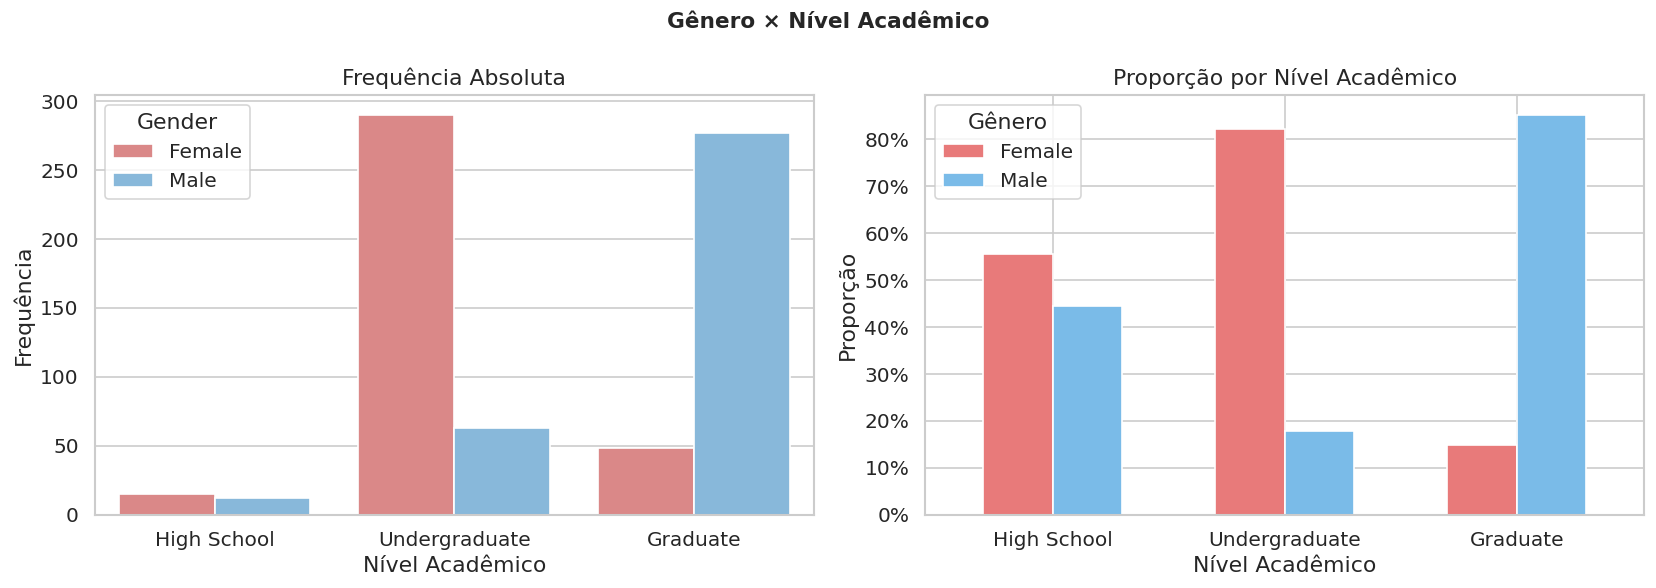

In [12]:
# Visualização da associação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gênero × Nível Acadêmico', fontsize=13, fontweight='bold')

order_acad = ['High School', 'Undergraduate', 'Graduate']

# Contagem absoluta
sns.countplot(data=df, x='Academic_Level', hue='Gender',
              order=order_acad, palette=CORES_GENERO, ax=axes[0])
axes[0].set_title('Frequência Absoluta')
axes[0].set_xlabel('Nível Acadêmico')
axes[0].set_ylabel('Frequência')

# Proporção
prop = df.groupby('Academic_Level')['Gender'].value_counts(normalize=True).unstack()
prop = prop.reindex(order_acad)
prop.plot(kind='bar', ax=axes[1], color=[CORES_GENERO['Female'], CORES_GENERO['Male']],
          edgecolor='white', width=0.6)
axes[1].set_title('Proporção por Nível Acadêmico')
axes[1].set_xlabel('Nível Acadêmico')
axes[1].set_ylabel('Proporção')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gênero')

plt.tight_layout()
plt.savefig('genero_nivel_academico.png', bbox_inches='tight')
plt.show()

**Interpretação:** O teste Qui-Quadrado confirma associação significativa entre gênero e nível acadêmico (χ² >> valor crítico, p < 0.001). Na graduação, predominam mulheres; na pós-graduação, homens. Esse padrão pode refletir dinâmicas de acesso ao ensino superior e não necessariamente relação com uso de redes sociais.

### 3.5 Uso por Nível Acadêmico e Gênero

*** USO MÉDIO POR NÍVEL ACADÊMICO ***
                Média  Mediana  Desvio Padrão
Academic_Level                               
High School      5.54      5.6           0.69
Undergraduate    5.00      4.7           1.30
Graduate         4.78      4.7           1.23

*** USO MÉDIO POR GÊNERO ***
        Média  Mediana
Gender                
Female   5.01      4.8
Male     4.83      4.7


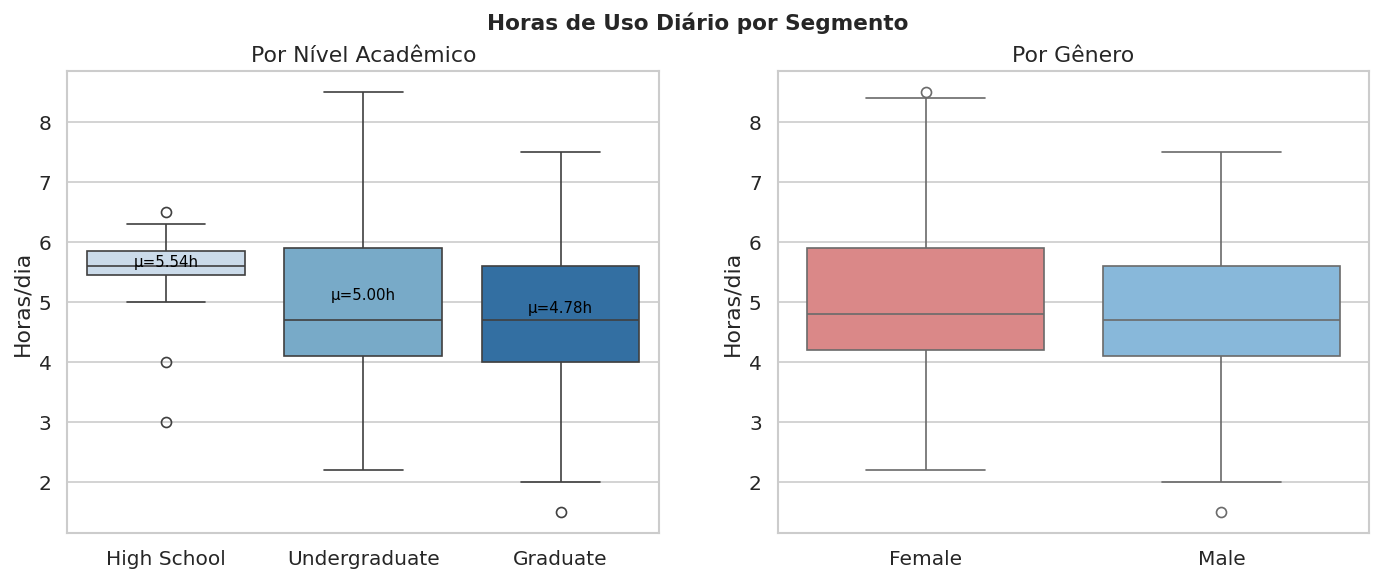

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Horas de Uso Diário por Segmento', fontsize=13, fontweight='bold')

order_acad = ['High School', 'Undergraduate', 'Graduate']

# Por nível acadêmico
sns.boxplot(data=df, x='Academic_Level', y='Avg_Daily_Usage_Hours',
            order=order_acad, palette='Blues', ax=axes[0])
medias = df.groupby('Academic_Level')['Avg_Daily_Usage_Hours'].mean().reindex(order_acad)
for i, (nivel, media) in enumerate(medias.items()):
    axes[0].annotate(f'μ={media:.2f}h', xy=(i, media), ha='center',
                     va='bottom', fontsize=9, color='black')
axes[0].set_title('Por Nível Acadêmico')
axes[0].set_xlabel('')
axes[0].set_ylabel('Horas/dia')

# Por gênero
sns.boxplot(data=df, x='Gender', y='Avg_Daily_Usage_Hours',
            palette=CORES_GENERO, ax=axes[1])
axes[1].set_title('Por Gênero')
axes[1].set_xlabel('')
axes[1].set_ylabel('Horas/dia')

# Tabela resumo
print('*** USO MÉDIO POR NÍVEL ACADÊMICO ***')
print(df.groupby('Academic_Level')['Avg_Daily_Usage_Hours']
        .agg(['mean', 'median', 'std']).round(2)
        .rename(columns={'mean': 'Média', 'median': 'Mediana', 'std': 'Desvio Padrão'})
        .reindex(order_acad))
print('\n*** USO MÉDIO POR GÊNERO ***')
print(df.groupby('Gender')['Avg_Daily_Usage_Hours']
        .agg(['mean', 'median']).round(2)
        .rename(columns={'mean': 'Média', 'median': 'Mediana'}))

### 3.6 Impacto no Desempenho Acadêmico

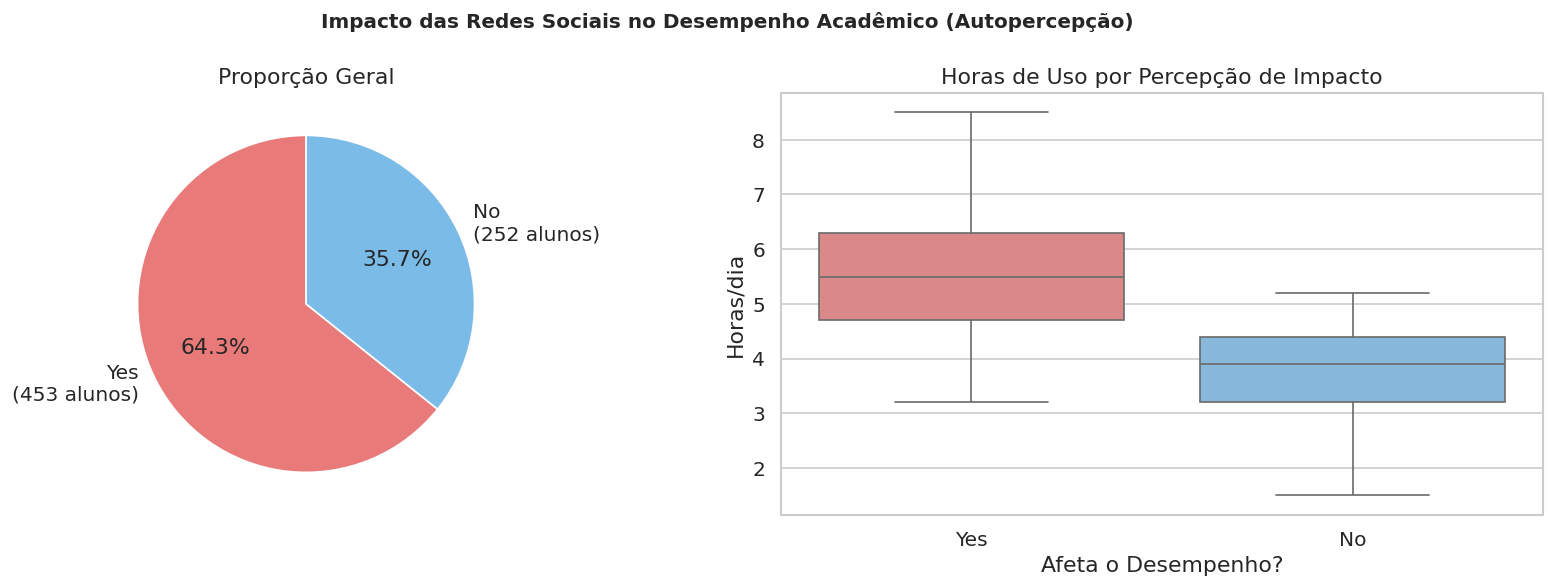

*** USO MÉDIO POR PERCEPÇÃO DE IMPACTO ***
                              Média  Mediana    N
Affects_Academic_Performance                     
No                             3.80      3.9  252
Yes                            5.54      5.5  453


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto das Redes Sociais no Desempenho Acadêmico (Autopercepção)',
             fontsize=12, fontweight='bold')

# Distribuição geral
counts = df['Affects_Academic_Performance'].value_counts()
axes[0].pie(counts, labels=[f'{l}\n({v} alunos)' for l, v in zip(counts.index, counts.values)],
            autopct='%1.1f%%', colors=['#E87A7A', '#7ABBE8'], startangle=90)
axes[0].set_title('Proporção Geral')

# Horas de uso por percepção
sns.boxplot(data=df, x='Affects_Academic_Performance', y='Avg_Daily_Usage_Hours',
            palette={'Yes': '#E87A7A', 'No': '#7ABBE8'}, ax=axes[1])
axes[1].set_title('Horas de Uso por Percepção de Impacto')
axes[1].set_xlabel('Afeta o Desempenho?')
axes[1].set_ylabel('Horas/dia')

plt.tight_layout()
plt.savefig('impacto_academico.png', bbox_inches='tight')
plt.show()

print('*** USO MÉDIO POR PERCEPÇÃO DE IMPACTO ***')
print(df.groupby('Affects_Academic_Performance')['Avg_Daily_Usage_Hours']
        .agg(['mean', 'median', 'count']).round(2)
        .rename(columns={'mean': 'Média', 'median': 'Mediana', 'count': 'N'}))

**Insight:** Estudantes que relatam impacto negativo no desempenho têm, em média, significativamente mais horas de uso diário. Isso reforça a narrativa de que uso intensivo está correlacionado com percepção de prejuízo acadêmico.

### 3.7 Mapa de Correlação Geral

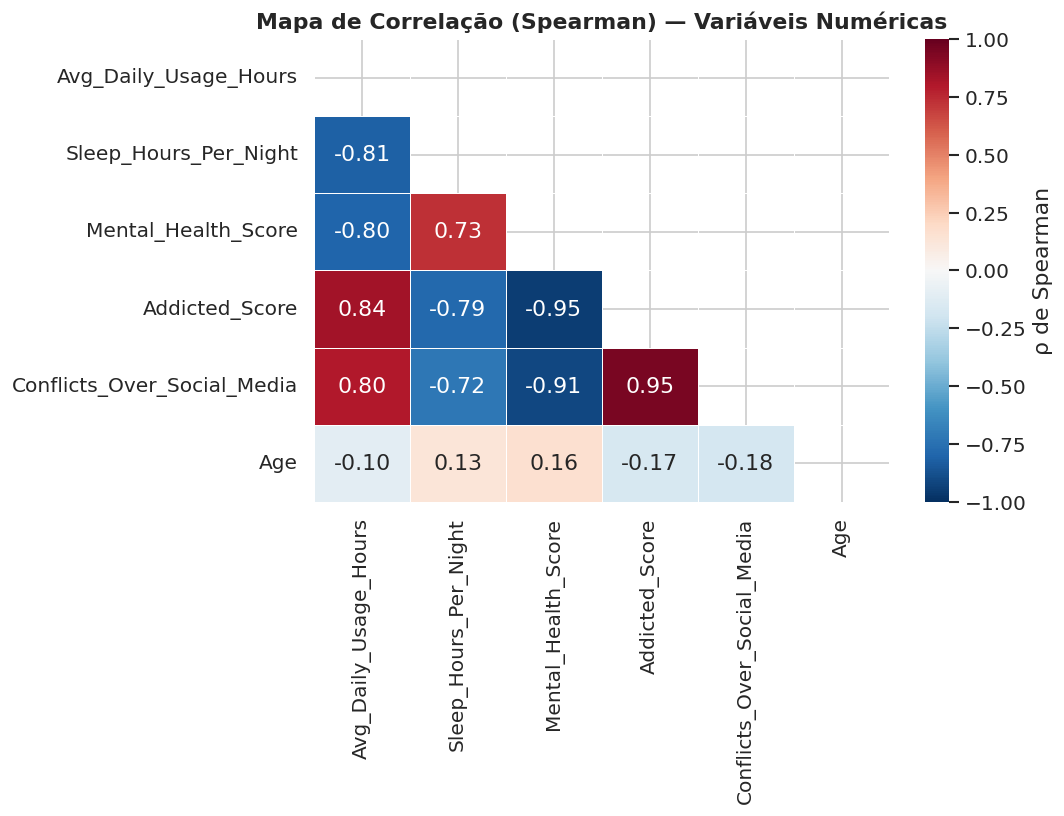

In [16]:
numericas = df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                'Mental_Health_Score', 'Addicted_Score',
                'Conflicts_Over_Social_Media', 'Age']]

# Matriz de correlação de Spearman
corr_matrix = numericas.corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'ρ de Spearman'})
plt.title('Mapa de Correlação (Spearman) — Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', bbox_inches='tight')
plt.show()

---
## 4. Análise SQL com SQLite

Nesta seção, carregamos o dataset em um banco de dados SQLite em memória e utilizamos SQL para responder perguntas de negócio — demonstrando como dados tabulares podem ser explorados com queries relacionais.


In [17]:
# Criando banco SQLite em memória e carregando o dataset
conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')

def run_sql(query, titulo=None):
    """Executa uma query SQL e retorna o resultado como DataFrame."""
    result = pd.read_sql_query(query, conn)
    if titulo:
        print(f'\n=== {titulo} ===')
    return result

print('✅ Banco SQLite criado com sucesso!')
run_sql('SELECT COUNT(*) AS total_registros FROM students', 'Total de registros')

✅ Banco SQLite criado com sucesso!

=== Total de registros ===


,total_registros
0,705


### Query 1 — Perfil médio por nível acadêmico

In [18]:
q1 = """
SELECT
    Academic_Level,
    COUNT(*)                                       AS total_alunos,
    ROUND(AVG(Avg_Daily_Usage_Hours), 2)           AS media_horas_uso,
    ROUND(AVG(Sleep_Hours_Per_Night), 2)           AS media_horas_sono,
    ROUND(AVG(Mental_Health_Score), 2)             AS media_saude_mental,
    ROUND(AVG(Addicted_Score), 2)                  AS media_dependencia
FROM students
GROUP BY Academic_Level
ORDER BY media_horas_uso DESC
"""
run_sql(q1, 'PERFIL MÉDIO POR NÍVEL ACADÊMICO')


=== PERFIL MÉDIO POR NÍVEL ACADÊMICO ===


,Academic_Level,total_alunos,media_horas_uso,media_horas_sono,media_saude_mental,media_dependencia
0,High School,27,5.54,5.46,5.11,8.04
1,Undergraduate,353,5.00,6.83,6.18,6.49
2,Graduate,325,4.78,7.03,6.37,6.24


### Query 2 — Plataformas com maior dependência média (Top 5)

In [19]:
q2 = """
SELECT
    Most_Used_Platform,
    COUNT(*)                                   AS total_usuarios,
    ROUND(AVG(Addicted_Score), 2)              AS media_dependencia,
    ROUND(AVG(Mental_Health_Score), 2)         AS media_saude_mental,
    ROUND(AVG(Avg_Daily_Usage_Hours), 2)       AS media_horas_uso
FROM students
GROUP BY Most_Used_Platform
HAVING COUNT(*) >= 10
ORDER BY media_dependencia DESC
LIMIT 5
"""
run_sql(q2, 'TOP 5 PLATAFORMAS POR DEPENDÊNCIA MÉDIA (mín. 10 usuários)')


=== TOP 5 PLATAFORMAS POR DEPENDÊNCIA MÉDIA (mín. 10 usuários) ===


,Most_Used_Platform,total_usuarios,media_dependencia,media_saude_mental,media_horas_uso
0,WhatsApp,54,7.46,5.54,6.48
1,Snapchat,13,7.46,5.54,5.09
2,TikTok,154,7.43,5.71,5.35
3,Instagram,249,6.55,6.12,4.87
4,YouTube,10,6.10,6.60,4.08


### Query 3 — Segmentação por nível de uso

In [20]:
q3 = """
WITH uso_categorizado AS (
    SELECT *,
        CASE
            WHEN Avg_Daily_Usage_Hours < 3   THEN '🟢 Baixo (<3h)'
            WHEN Avg_Daily_Usage_Hours < 5   THEN '🟡 Moderado (3–5h)'
            WHEN Avg_Daily_Usage_Hours < 7   THEN '🟠 Alto (5–7h)'
            ELSE                                  '🔴 Muito Alto (≥7h)'
        END AS categoria_uso
    FROM students
)
SELECT
    categoria_uso,
    COUNT(*)                                       AS total_alunos,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM students), 1) AS pct_total,
    ROUND(AVG(Mental_Health_Score), 2)             AS media_saude_mental,
    ROUND(AVG(Sleep_Hours_Per_Night), 2)           AS media_horas_sono,
    ROUND(AVG(Addicted_Score), 2)                  AS media_dependencia,
    SUM(CASE WHEN Affects_Academic_Performance = 'Yes' THEN 1 ELSE 0 END) AS afeta_academico
FROM uso_categorizado
GROUP BY categoria_uso
ORDER BY Avg_Daily_Usage_Hours
"""
run_sql(q3, 'SEGMENTAÇÃO POR NÍVEL DE USO (CTE)')


=== SEGMENTAÇÃO POR NÍVEL DE USO (CTE) ===


,categoria_uso,total_alunos,pct_total,media_saude_mental,media_horas_sono,media_dependencia,afeta_academico
0,🟢 Baixo (<3h),43,6.1,7.91,8.15,3.91,0
1,🟡 Moderado (3–5h),354,50.2,6.77,7.47,5.62,151
2,🟠 Alto (5–7h),263,37.3,5.46,6.16,7.59,257
3,🔴 Muito Alto (≥7h),45,6.4,4.82,5.11,8.53,45


### Query 4 — Estudantes em zona de risco

In [21]:
q4 = """
SELECT
    Gender,
    Academic_Level,
    COUNT(*)                                    AS total_em_risco,
    ROUND(AVG(Avg_Daily_Usage_Hours), 2)        AS media_horas_uso,
    ROUND(AVG(Mental_Health_Score), 2)          AS media_saude_mental
FROM students
WHERE
    Avg_Daily_Usage_Hours > 6          -- uso intensivo
    AND Mental_Health_Score <= 5       -- saúde mental comprometida
    AND Sleep_Hours_Per_Night < 6      -- privação de sono
    AND Addicted_Score >= 7            -- alta dependência
GROUP BY Gender, Academic_Level
ORDER BY total_em_risco DESC
"""
resultado_risco = run_sql(q4, 'ESTUDANTES EM ZONA DE RISCO (múltiplos critérios)')
print(resultado_risco)
total_risco = resultado_risco['total_em_risco'].sum()
print(f'\nTotal de estudantes em zona de risco: {total_risco}/{len(df)} ({total_risco/len(df):.1%})')


=== ESTUDANTES EM ZONA DE RISCO (múltiplos critérios) ===
   Gender Academic_Level  total_em_risco  media_horas_uso  media_saude_mental
0  Female  Undergraduate              42             7.25                4.60
1    Male       Graduate              16             6.97                4.75
2  Female    High School               5             6.24                4.80
3    Male  Undergraduate               3             7.07                4.00
4  Female       Graduate               2             6.90                4.00

Total de estudantes em zona de risco: 68/705 (9.6%)


### Query 5 — Ranking de dependência por plataforma e gênero

In [22]:
q5 = """
WITH plataforma_genero AS (
    SELECT
        Most_Used_Platform,
        Gender,
        COUNT(*)                              AS n,
        ROUND(AVG(Addicted_Score), 2)         AS media_dependencia,
        ROUND(AVG(Mental_Health_Score), 2)    AS media_saude_mental
    FROM students
    GROUP BY Most_Used_Platform, Gender
    HAVING COUNT(*) >= 5
),
ranking AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY Gender
            ORDER BY media_dependencia DESC
        ) AS rank_dependencia
    FROM plataforma_genero
)
SELECT *
FROM ranking
WHERE rank_dependencia <= 3
ORDER BY Gender, rank_dependencia
"""
run_sql(q5, 'TOP 3 PLATAFORMAS POR DEPENDÊNCIA — SEGMENTADO POR GÊNERO (Window Function)')


=== TOP 3 PLATAFORMAS POR DEPENDÊNCIA — SEGMENTADO POR GÊNERO (Window Function) ===


,Most_Used_Platform,Gender,n,media_dependencia,media_saude_mental,rank_dependencia
0,WhatsApp,Female,11,7.64,5.36,1
1,TikTok,Female,86,7.52,5.67,2
2,Snapchat,Female,8,7.50,5.63,3
3,WhatsApp,Male,43,7.42,5.58,1
4,Snapchat,Male,5,7.40,5.40,2
5,TikTok,Male,68,7.31,5.76,3


---
## 5. Conclusões e Insights

### 📊 Resumo dos Principais Achados

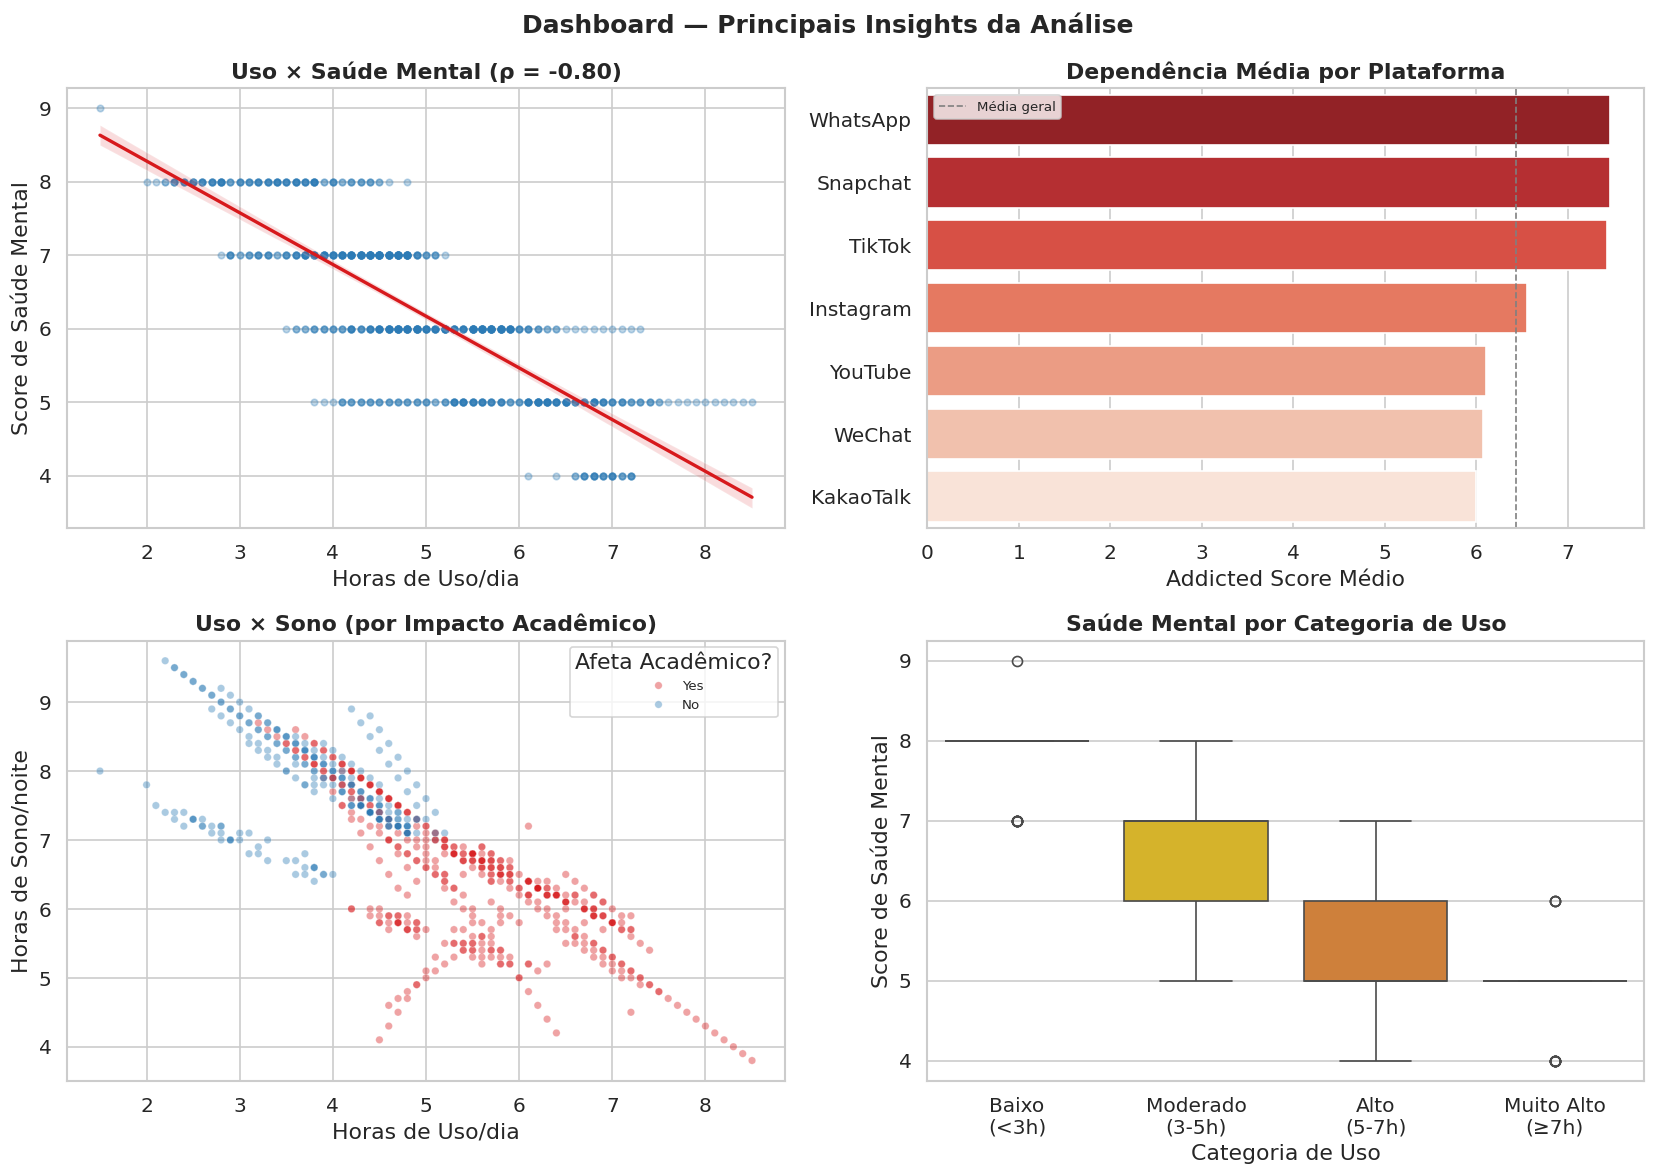

💾 Dashboard salvo como dashboard_insights.png


In [25]:
# Dashboard resumo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard — Principais Insights da Análise', fontsize=15, fontweight='bold')

# 1. Uso vs Saúde Mental
sns.regplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',
            ax=axes[0, 0], scatter_kws={'alpha': 0.3, 's': 15, 'color': COR_PRINCIPAL},
            line_kws={'color': COR_DESTAQUE, 'linewidth': 2})
rho, _ = spearmanr(df['Avg_Daily_Usage_Hours'], df['Mental_Health_Score'])
axes[0, 0].set_title(f'Uso × Saúde Mental (ρ = {rho:.2f})', fontweight='bold')
axes[0, 0].set_xlabel('Horas de Uso/dia')
axes[0, 0].set_ylabel('Score de Saúde Mental')

# 2. Dependência por plataforma
plat_dep = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=False).head(7)
sns.barplot(y=plat_dep.index, x=plat_dep.values, ax=axes[0, 1], palette='Reds_r')
axes[0, 1].set_title('Dependência Média por Plataforma', fontweight='bold')
axes[0, 1].set_xlabel('Addicted Score Médio')
axes[0, 1].set_ylabel('')
axes[0, 1].axvline(df['Addicted_Score'].mean(), color='gray',
                    linestyle='--', linewidth=1, label='Média geral')
axes[0, 1].legend(fontsize=8)

# 3. Sono vs Uso
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night',
                hue='Affects_Academic_Performance',
                palette={'Yes': COR_DESTAQUE, 'No': COR_PRINCIPAL},
                alpha=0.4, s=20, ax=axes[1, 0])
axes[1, 0].set_title('Uso × Sono (por Impacto Acadêmico)', fontweight='bold')
axes[1, 0].set_xlabel('Horas de Uso/dia')
axes[1, 0].set_ylabel('Horas de Sono/noite')
axes[1, 0].legend(title='Afeta Acadêmico?', fontsize=8)

# 4. Distribuição de saúde mental por nível de uso
df['categoria_uso'] = pd.cut(df['Avg_Daily_Usage_Hours'],
                              bins=[0, 3, 5, 7, 10],
                              labels=['Baixo\n(<3h)', 'Moderado\n(3-5h)',
                                      'Alto\n(5-7h)', 'Muito Alto\n(≥7h)'])
sns.boxplot(data=df, x='categoria_uso', y='Mental_Health_Score',
            palette=['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C'], ax=axes[1, 1])
axes[1, 1].set_title('Saúde Mental por Categoria de Uso', fontweight='bold')
axes[1, 1].set_xlabel('Categoria de Uso')
axes[1, 1].set_ylabel('Score de Saúde Mental')

plt.tight_layout()
plt.savefig('dashboard_insights.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Dashboard salvo como dashboard_insights.png')

---

## 📝 Conclusões Finais

### Principais insights

**1. Uso intensivo compromete saúde mental e sono**  
As correlações de Spearman confirmaram relações negativas muito fortes entre horas de uso e saúde mental (ρ ≈ −0.80) e sono (ρ ≈ −0.81), ambas estatisticamente significativas (p < 0.001). Estudantes com uso ≥ 7h/dia apresentam scores de saúde mental consistentemente mais baixos.

**2. Quase metade dos estudantes usa redes sociais intensivamente**  
Com 95% de confiança, entre 43,7% e 51,1% da população de estudantes usa redes sociais por mais de 5 horas diárias — uma proporção expressiva.

**3. Gênero e nível acadêmico estão associados**  
O Qui-Quadrado confirmou associação significativa (χ² > 300, p < 0.001): na graduação predominam mulheres; na pós-graduação, homens.

**4. 64% relatam impacto negativo no desempenho**  
E os que relatam impacto têm média de uso significativamente maior — sugerindo que a autopercepção é coerente com o comportamento.

**5. TikTok e Instagram lideram em dependência**  
As plataformas de conteúdo de curto formato aparecem com maiores scores médios de dependência nas análises SQL.

### Limitações
- Dados autodeclarados — sujeitos a viés de resposta.
- Amostra desbalanceada por nível acadêmico (apenas 27 do ensino médio).
- Correlação ≠ causalidade. Fatores externos não mensurados podem influenciar os resultados.

---

*Projeto desenvolvido para fins de portfólio e aprendizado em análise de dados da disciplina de Análise Exploratória dos Dados e Métodos Estatísticos - USP .*  
*Dataset: [Kaggle — Students' Social Media Addiction](https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships)*